# Aprendizaje Automático
# Trabajo Práctico 2

Profesor: Juan Luis Crespo Mariño

Instituto Tecnológico de Costa Rica,

Programa Ciencia de Datos

---

Fecha de entrega: 11 de agosto, hora límite las 6:00 pm.

Medio de entrega: Por medio del TEC-Digital.

Entregables: Un archivo jupyter ( .IPYNB ).

BD utilizada: https://archive.ics.uci.edu/dataset/2/adult


Estudiante:
1. **Jose Pablo Ruiz Myrie**
2. **Nikole Villalobos Lopez**


# Notebook 01 — EDA inicial, valores faltantes y outliers

Este notebook contiene la exploración inicial del dataset Adult, el análisis
de su estructura, el tratamiento de valores faltantes y el estudio de valores
atípicos mediante análisis descriptivo, histogramas, boxplots e IQR.


In [ ]:
pip install ucimlrepo

In [ ]:
# ============================================================
# 0. Cargamos las librerias
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer



In [ ]:
# ============================================================
# PARTE 1. Introducción al dataset, carga, estructura
# ============================================================

# Este dataset contiene información demográfica, eduactiva y laboral sobre
# individuos recopilados a partir del censo de Estados Unidos de 1994.
#
# Los datos incluyen características como edad, nivel educativo, ocupación,
# estado civil, tipo de empleo, cantidad de horas trabajadas por semana,
# ganancias de capital y país de origen. Contamos con datos faltantes para
# native-country  workclass y occupation
#
# El objetivo principal del conjunto de datos es analizar los factores asociados
# al nivel de ingresos de las personas y clasificar si un individuo posee un
# ingreso anual superior o inferior a 50 000 dólares

#Descargamos el repo
from ucimlrepo import fetch_ucirepo

# fetch dataset
adult = fetch_ucirepo(id=2)

# data (as pandas dataframes)
X = adult.data.features
y = adult.data.targets

# Unimos las variables predictoras con la variable objetivo
df = pd.concat([X, y], axis=1)

# Visualizamos las primeras filas
df.head()

print("=" * 60)
print("Dimensiones del dataset (filas, columnas):")
print(df.shape)

print("\n" + "=" * 60)
print("Primeras 10 filas:")
print(df.head(10))

print("\n" + "=" * 60)
print("Tipos de datos por columna:")
print(df.dtypes)

print("\n" + "=" * 60)
print("Valores nulos por columna:")
print(df.isnull().sum())

print("\n" + "=" * 60)
print("Estadísticos descriptivos de las variables numéricas:")
print(df.describe())

print("\n" + "=" * 60)
print("Cantidad de filas duplicadas:")
print(df.duplicated().sum())

print("=" * 60)




Dimensiones del dataset (filas, columnas):
(48842, 15)

Primeras 10 filas:
   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   
5   37           Private  284582    Masters             14   
6   49           Private  160187        9th              5   
7   52  Self-emp-not-inc  209642    HS-grad              9   
8   31           Private   45781    Masters             14   
9   42           Private  159449  Bachelors             13   

          marital-status         occupation   relationship   race     sex  \
0          Never-married       Adm-clerical  Not-in-family  White    Male   
1     Married-civ-spouse    Exec-managerial        Husband  White    Male   
2          

In [ ]:
# ============================================================
# PARTE 2. Tratamiento de valores faltantes
# ============================================================

#Explicacion de porque utilizamos imputacion


#Contamos la cantidad de faltantes
print("=" * 60)
faltantes = (df == "?").sum()

print(faltantes[faltantes > 0])
print("=" * 60)

faltantes = (df == "?").sum()
porcentaje_faltantes = (faltantes / len(df)) * 100

resultado = pd.DataFrame({
    "Cantidad de faltantes": faltantes,
    "Porcentaje": porcentaje_faltantes
})

resultado = resultado[resultado["Cantidad de faltantes"] > 0]

print(resultado)


#Ahora vemos cual es la moda de cada categoria de faltantes
print("=" * 60)
for columna in ["workclass", "occupation", "native-country"]:
    moda = df.loc[df[columna] != "?", columna].mode()[0]
    frecuencia = (df[columna] == moda).sum()

    print(f"{columna}:")
    print(f"  Moda: {moda}")
    print(f"  Frecuencia: {frecuencia}")
    print()


print("=" * 60)


#Hacemos la imputación, donde sustituimos los ? por NA y luego por la moda


columnas_faltantes = ["workclass", "occupation", "native-country"]

df[columnas_faltantes] = df[columnas_faltantes].replace("?", np.nan)


imputer = SimpleImputer(strategy="most_frequent")

df[columnas_faltantes] = imputer.fit_transform(
    df[columnas_faltantes]
)

print(df[columnas_faltantes].isnull().sum())

workclass         1836
occupation        1843
native-country     583
dtype: int64
                Cantidad de faltantes  Porcentaje
workclass                        1836    3.759060
occupation                       1843    3.773392
native-country                    583    1.193645
workclass:
  Moda: Private
  Frecuencia: 33906

occupation:
  Moda: Prof-specialty
  Frecuencia: 6172

native-country:
  Moda: United-States
  Frecuencia: 43832

workclass         0
occupation        0
native-country    0
dtype: int64


In [ ]:
# ============================================================
# PARTE 3. Tratamiento de outliers
# ============================================================

# Realizamos un análisis descriptivo de las variables con el fin de conocer
# sus principales características. Al comparar la mediana con la media de
# variables como age, education-num y hours-per-week, observamos que sus valores
# son relativamente cercanos. Esto sugiere que estas variables no presentan
# una asimetría extremadamente marcada. Sin embargo, esta comparación por sí
# sola no permite determinar la presencia o ausencia de valores atípicos.
# Además, podemos observar que, para estas variables, los valores mínimos y
# máximos pueden considerarse plausibles de acuerdo con el significado de cada
# variable. Por ejemplo, en age encontramos edades entre 17 y 90 años, valores
# que son posibles dentro de la población analizada. Por lo tanto, aunque algunos
# de estos valores puedan ser identificados posteriormente como atípicos mediante
# métodos estadísticos, esto no significa necesariamente que sean errores.
# Por otro lado, la desviación estándar de estas variables nos permite evaluar
# qué tan dispersos se encuentran los datos respecto a su media. No obstante,
# una desviación estándar elevada o reducida no permite, por sí sola, confirmar
# la presencia o ausencia de outliers, por lo que será necesario complementar
# este análisis con métodos como IQR y herramientas gráficas como el boxplot.
# En contraste, capital-gain y capital-loss presentan una distribución mucho
# más particular. En estas variables existe una fuerte concentración de valores
# en 0 y algunos valores positivos considerablemente más altos. Esto provoca una
# diferencia importante entre la media y la mediana, así como una mayor dispersión.
# Por lo tanto, estas variables presentan una fuerte asimetría positiva y requieren
# un análisis especial antes de considerar sus valores extremos como outliers.

print("=" * 60)
numeric_cols = [
    'age',
    'fnlwgt',
    'education-num',
    'capital-gain',
    'capital-loss',
    'hours-per-week'
]

df[numeric_cols].describe().T
print(numeric_cols)
print("=" * 60)



['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']


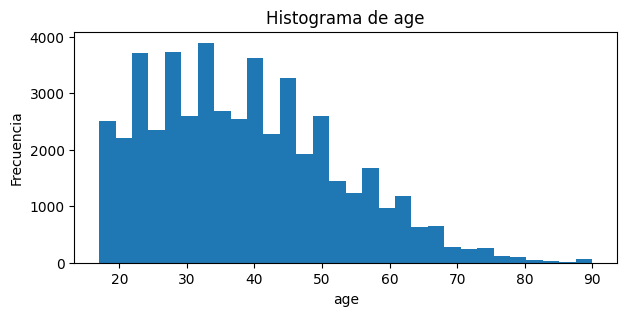

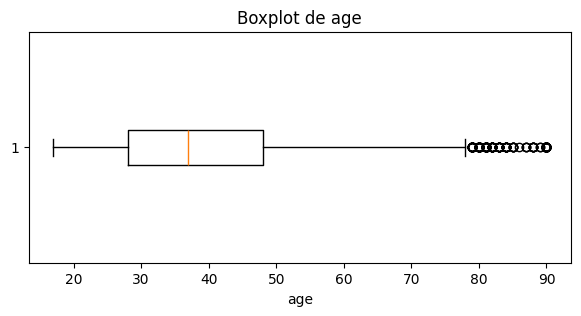

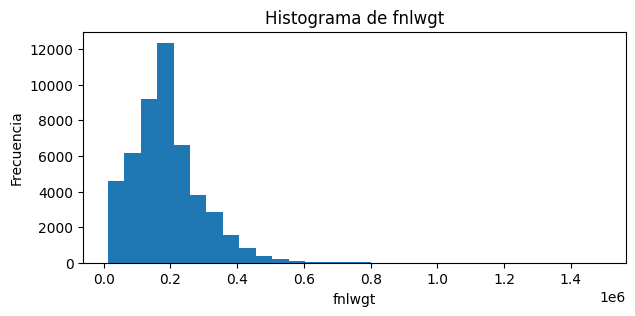

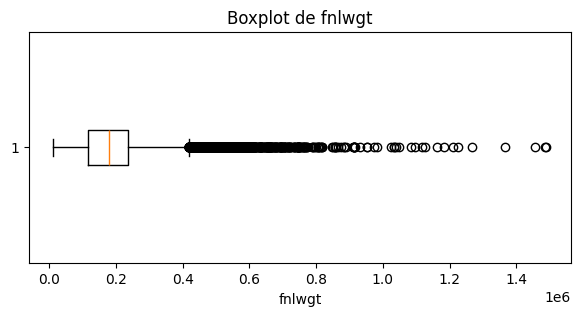

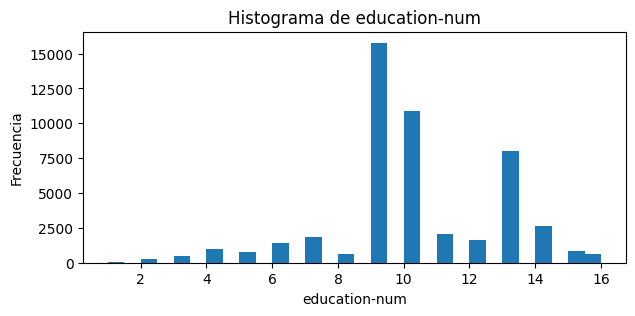

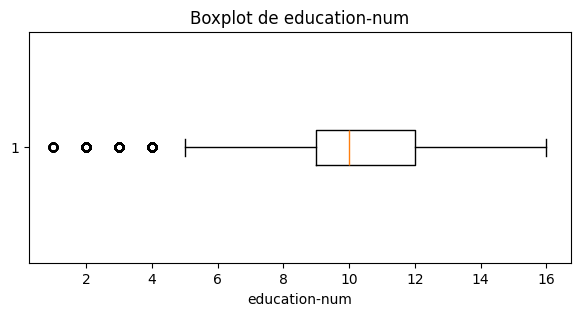

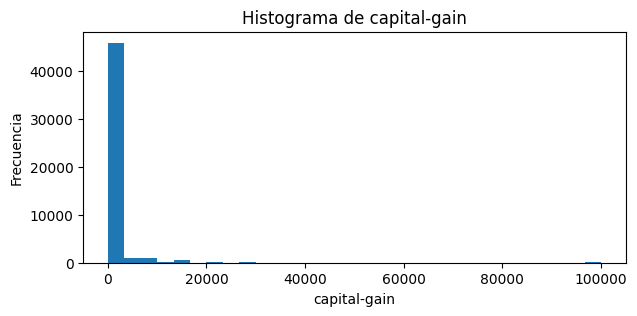

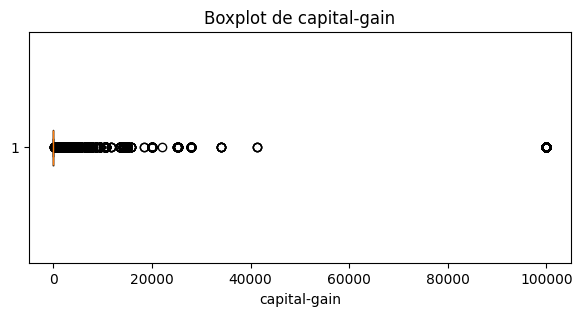

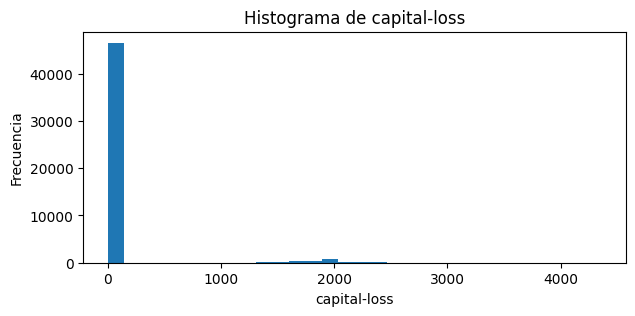

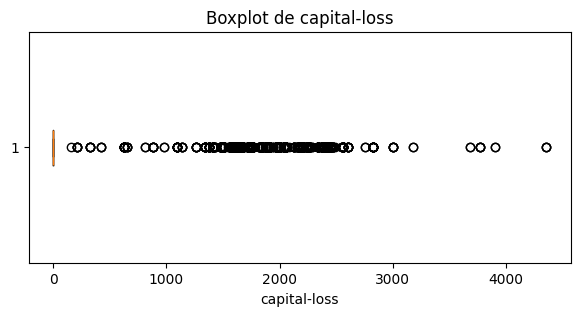

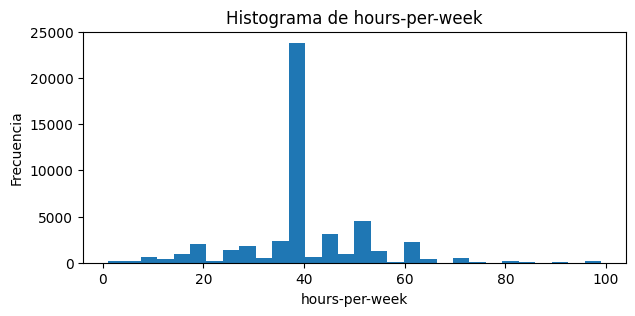

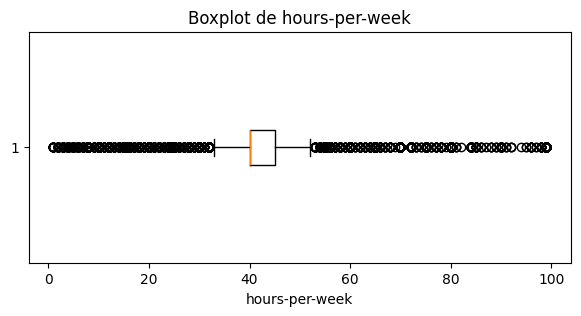

In [ ]:
# Seguidamente, realizamos el histograma y el boxplot para cada una de las variables.
# Podemos observar que varias de ellas presentan distribuciones asimétricas, con una
# mayor concentración de observaciones en determinados rangos y colas hacia valores
# extremos.
# También podemos observar cómo capital-gain y capital-loss concentran una gran cantidad
# de sus valores en 0. Debemos recordar que estas variables corresponden a ganancias y
# pérdidas de capital, respectivamente. Por lo tanto, es razonable encontrar una alta
# concentración de valores en cero, ya que una gran parte de la población no reporta
# ganancias o pérdidas de capital.
# Ahora bien, al analizar los boxplots podemos observar que age presenta puntos fuera
# del bigote superior. Esto indica que las edades más elevadas son consideradas
# estadísticamente atípicas respecto a la distribución de la variable. Sin embargo,
# como verificamos anteriormente, estas edades son plausibles, por lo que no deben
# considerarse automáticamente como errores ni eliminarse.
# Seguidamente, observamos que los boxplots de capital-gain y capital-loss presentan
# una caja que visualmente parece una línea. Esto ocurre debido a que una gran cantidad
# de observaciones se concentra en 0, provocando que los cuartiles estén muy próximos
# o incluso coincidan. Como consecuencia, el IQR puede ser igual a 0 y los valores
# positivos aparecen visualmente como valores atípicos.

for col in numeric_cols:
    plt.figure(figsize=(7, 3))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f'Histograma de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()

    plt.figure(figsize=(7, 3))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f'Boxplot de {col}')
    plt.xlabel(col)
    plt.show()

In [ ]:
#Definimos una funcion para realizar el método IQR para detectar posibles outliers.

def analizar_outliers_iqr(df, columna):

    # Primer cuartil
    Q1 = df[columna].quantile(0.25)

    # Tercer cuartil
    Q3 = df[columna].quantile(0.75)

    # Rango intercuartílico
    IQR = Q3 - Q1

    # Límites inferior y superior
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Identificar valores fuera de los límites
    mascara_outliers = (
        (df[columna] < limite_inferior) |
        (df[columna] > limite_superior)
    )

    # Número de outliers
    n_outliers = mascara_outliers.sum()

    # Porcentaje de outliers
    porcentaje_outliers = mascara_outliers.mean() * 100

    return {
        'variable': columna,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior,
        'n_outliers': n_outliers,
        'porcentaje_outliers': porcentaje_outliers
    }

In [ ]:
# Aplicamos IQR a todas las variables numéricas y observamos los resultados en la tabla.
# Vemos ciertas particularidades. Por ejemplo, el límite inferior de IQR para age es -2,
# mientras que el valor mínimo observado es 17, por lo que no existen outliers inferiores
# en esta variable. Lo mismo sucede para fnlwgt.
# Ahora bien, podemos ver que el IQR marca como outliers los valores de edad mayores a 78.
# Sin embargo, el valor máximo que encontramos en el dataset es de 90 años, lo cual es
# plausible, por lo que estos outliers no deben eliminarse.
# De la misma forma, se consideran outliers los valores de education-num que se encuentran
# fuera del intervalo entre 4.5 y 16.5. No obstante, ya verificamos que los valores máximos
# y mínimos observados en esta variable corresponden a niveles educativos válidos, por lo
# que no debemos eliminarlos.
# Para capital-gain, capital-loss y hours-per-week también es necesario analizar los valores
# atípicos antes de decidir si deben eliminarse.
# Más específicamente, la variable capital-gain presenta una fuerte concentración en cero,
# por lo que obtenemos un IQR de 0. Como consecuencia, el método IQR clasifica los valores
# positivos como atípicos. Este resultado no debe interpretarse como evidencia de errores,
# sino como una consecuencia de la distribución altamente asimétrica de la variable.
# Por tanto, IQR no se utilizará como criterio de eliminación para capital-gain.

resultados_iqr = []

for columna in numeric_cols:
    resultado = analizar_outliers_iqr(df, columna)
    resultados_iqr.append(resultado)

tabla_iqr = pd.DataFrame(resultados_iqr)

tabla_iqr



,variable,Q1,Q3,IQR,limite_inferior,limite_superior,n_outliers,porcentaje_outliers
0,age,28.0,48.0,20.0,-2.00,78.00,216,0.442242
1,fnlwgt,117550.5,237642.0,120091.5,-62586.75,417779.25,1453,2.974899
2,education-num,9.0,12.0,3.0,4.50,16.50,1794,3.673068
3,capital-gain,0.0,0.0,0.0,0.00,0.00,4035,8.261332
4,capital-loss,0.0,0.0,0.0,0.00,0.00,2282,4.672208
5,hours-per-week,40.0,45.0,5.0,32.50,52.50,13496,27.631956


In [ ]:
# Una vez analizados los resultados obtenidos mediante el método IQR y consideradas
# las características propias de cada variable, se ha decidido mantener las
# observaciones identificadas como atípicas, ya que corresponden a valores válidos
# y pueden aportar información relevante para distinguir entre los individuos con
# ingresos superiores e inferiores a $50K.
# No obstante, se ha decidido aplicar una transformación logarítmica a las variables
# capital-gain y capital-loss. Aunque los valores atípicos presentes en estas variables
# son válidos y, por lo tanto, no se considera apropiado eliminarlos, ambas presentan
# una distribución fuertemente asimétrica y una alta concentración de observaciones
# en cero. La transformación logarítmica permitirá reducir la influencia relativa de
# los valores extremos y comprimir la escala de los valores positivos, conservando
# las observaciones originales.

# Transformación logarítmica
df['capital-gain-log'] = np.log1p(df['capital-gain'])
df['capital-loss-log'] = np.log1p(df['capital-loss'])